In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arnavmahajan1/telco-churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv


Dataset Shape (Rows, Columns): (7043, 21)


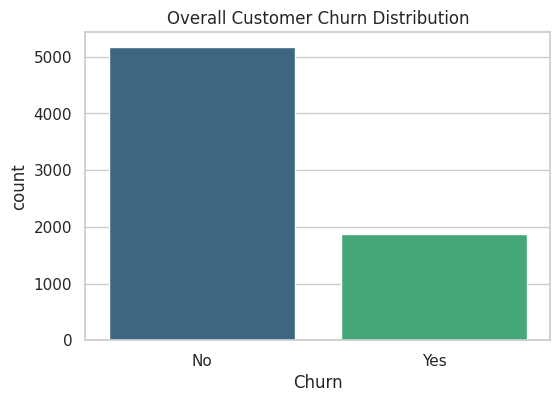

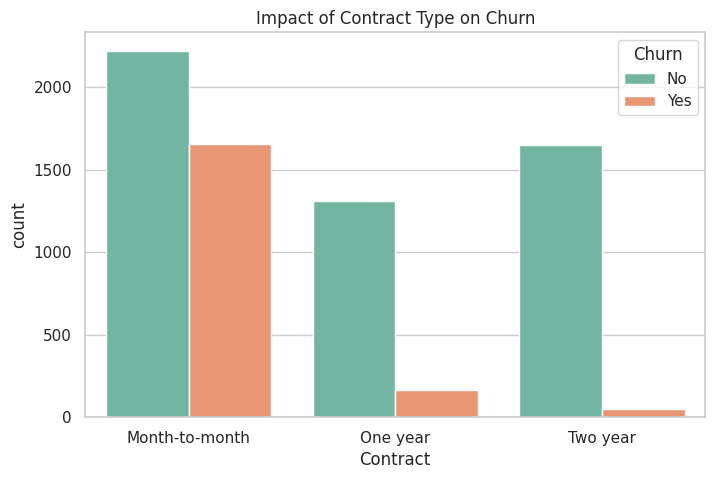

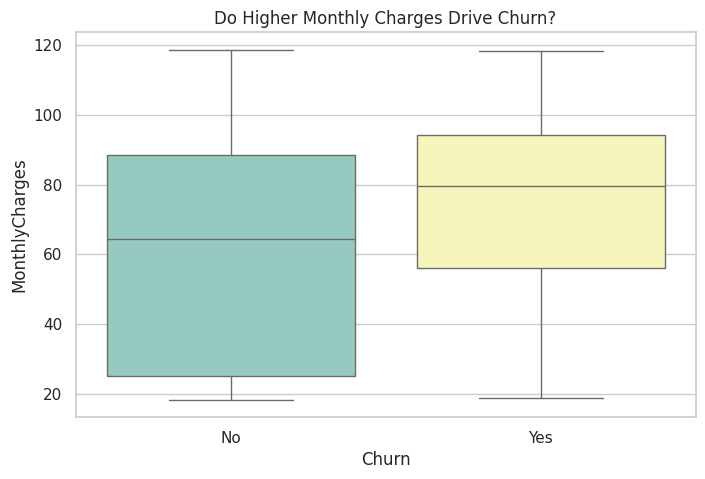

Object-type columns (will be one-hot encoded):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data is cleaned and ready for modeling. New shape: (7032, 31)


['feature_columns.pkl']

In [2]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc

# Set visual style for portfolio-quality graphs
sns.set_theme(style="whitegrid")

# 2. Load the dataset 
file_path = '/kaggle/input/datasets/arnavmahajan1/telco-churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

# 3. Initial Data Inspection
print("Dataset Shape (Rows, Columns):", df.shape)

# Drop the customerID column (note lowercase 'd' — must match exactly)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    
# 4. Exploratory Data Analysis (EDA) - The Business Insights
# A. Overall Churn Rate (UPDATED to fix warning)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Overall Customer Churn Distribution')
plt.show()

# B. Churn vs. Contract Type (Crucial for marketing!)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Impact of Contract Type on Churn')
plt.show()

# C. Churn vs. Monthly Charges (UPDATED to fix warning)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='Set3', legend=False)
plt.title('Do Higher Monthly Charges Drive Churn?')
plt.show()

# 5. Data Preprocessing (Making it ready for the Machine Learning Model)
# Convert 'Churn' from Yes/No to 1/0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Fix TotalCharges: it's stored as a string due to blank spaces
# Convert to numeric, coercing errors (blanks) to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges couldn't be parsed (usually ~11 rows)
df = df.dropna(subset=['TotalCharges'])

# Now verify no numeric columns are sneaking into object dtype
print("Object-type columns (will be one-hot encoded):")
print(df.select_dtypes(include=['object']).columns.tolist())
# Expected: ['gender', 'Partner', 'Dependents', 'PhoneService', 
#             'MultipleLines', 'InternetService', 'OnlineSecurity', 
#             'OnlineBackup', 'DeviceProtection', 'TechSupport', 
#             'StreamingTV', 'StreamingMovies', 'Contract', 
#             'PaperlessBilling', 'PaymentMethod']

# Identify text columns and One-Hot Encode them (Turn them into 0s and 1s)
categorical_cols = df.select_dtypes(include=['object']).columns
df_clean = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nData is cleaned and ready for modeling. New shape:", df_clean.shape)
# FIX 1: Drop TotalCharges — it's just MonthlyCharges × tenure in disguise
# Keeping it confuses the model and hides the truly actionable features
df_clean = df_clean.drop('TotalCharges', axis=1)

# Define feature columns and target
feature_columns = [col for col in df_clean.columns if col != 'Churn']
X = df_clean[feature_columns]
y = df_clean['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'  # ← This is the key addition
)
# Train the model
model.fit(X_train, y_train)

# Save model and feature columns
joblib.dump(model, "churn_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

# FIX 2: Handle class imbalance using class_weight
# This tells the model "pay extra attention to churners since there are fewer of them"
# It's like giving the minority class a louder voice during training




Training Random Forest...
Tuning XGBoost with GridSearchCV (This may take a minute...)
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 2.3, 'subsample': 0.8}
Best ROC-AUC score: 0.8526

--- Model Comparison Table ---
                     Model Cross-Validation Accuracy
  Random Forest (Baseline)                    78.79%
XGBoost (GridSearch Tuned)                    85.26%


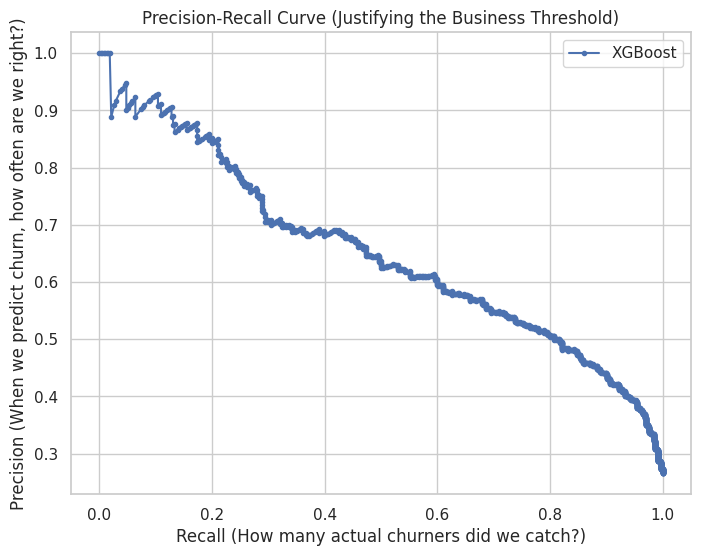


Superior XGBoost Model saved successfully!


In [3]:



# 6. Advanced Machine Learning Model Building & Comparison

# A. Split the data into Training (80%) and Testing (20%) sets
X = df_clean.drop('Churn', axis=1) 
y = df_clean['Churn']              
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# B. Set up K-Fold Cross Validation (Makes your results highly credible)
# This splits the training data into 5 chunks, testing the model on each one to ensure it isn't "getting lucky"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# C. Model 1: The Baseline Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# Calculate Cross-Validation accuracy
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')

# D. Model 2: XGBoost with GridSearchCV (The Heavy Hitter)
print("Tuning XGBoost with GridSearchCV (This may take a minute...)")
# scale_pos_weight handles the class imbalance for XGBoost
xgb_model = XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss')

param_grid = {
    'max_depth': [3, 4, 5],           # how deep each tree goes
    'learning_rate': [0.01, 0.05, 0.1], # how fast the model learns
    'n_estimators': [100, 200, 300],   # how many trees to build
    'subsample': [0.8, 1.0],          # fraction of rows used per tree
    'colsample_bytree': [0.8, 1.0],   # fraction of columns used per tree
    'scale_pos_weight': [2.3]         # fixes class imbalance (70/30 ratio)
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',    # ← this is the key fix, not accuracy
    n_jobs=-1,
    verbose=1             # shows progress so you know it's running
)

grid_search.fit(X_train, y_train)

# Print the best settings it found
print("Best parameters found:", grid_search.best_params_)
print("Best ROC-AUC score:", round(grid_search.best_score_, 4))
# Extract the winning model
best_xgb = grid_search.best_estimator_

# E. The Model Comparison Table (Proves you research before deploying)
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost (GridSearch Tuned)'],
    'Cross-Validation Accuracy': [f"{rf_cv_scores.mean()*100:.2f}%", f"{grid_search.best_score_*100:.2f}%"]
})
print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

# F. Precision-Recall Curve for the Winning Model
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', color='b', label='XGBoost')
plt.title('Precision-Recall Curve (Justifying the Business Threshold)')
plt.xlabel('Recall (How many actual churners did we catch?)')
plt.ylabel('Precision (When we predict churn, how often are we right?)')
plt.legend()
plt.show()

# G. Save the superior XGBoost model for your Streamlit App
joblib.dump(best_xgb, 'xgboost_churn_model.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')
print("\nSuperior XGBoost Model saved successfully!")


Generating SHAP AI Brain Scan for a specific customer...


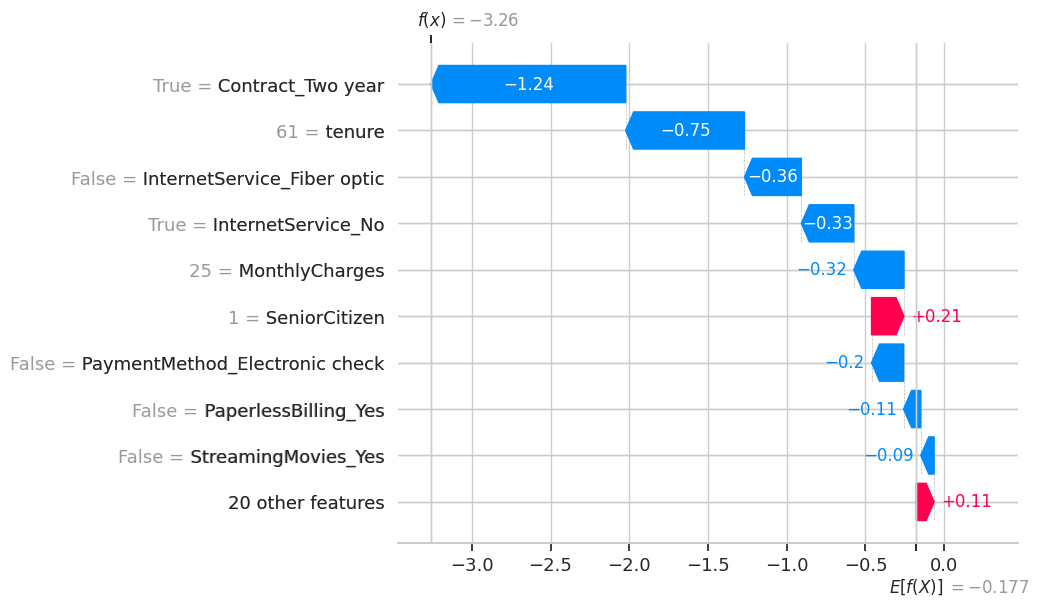

In [4]:
# 7. AI Brain Scan (SHAP Explanations)
# Note: Kaggle needs this installed first. 
!pip install shap

import shap
import matplotlib.pyplot as plt

print("\nGenerating SHAP AI Brain Scan for a specific customer...")

# A. Create the explainer using your winning model from Part 6
explainer = shap.TreeExplainer(best_xgb)

# B. Calculate SHAP values for your test data
shap_values = explainer(X_test)

# C. Generate the Waterfall plot for the very FIRST customer in your test set
# (You can change [0] to [1], [2], or [5] to look at different customers!)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10)
plt.show()

In [5]:


# Save the trained model to a file — think of this like hitting "Save" 
# on a Word document. Without this, your trained model disappears 
# when the session ends.
joblib.dump(model, 'churn_model.pkl')

# Also save the list of feature names — this is critical because when 
# someone sends new customer data later, it must be in EXACTLY the same 
# column order that the model was trained on. This file acts as a 
# "memory" of what the model expects.
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model and features saved successfully!")

Model and features saved successfully!


In [6]:
from IPython.display import FileLink

# This creates a clickable download link directly in your Kaggle notebook
# Click each link and the file will download to your computer
FileLink('churn_model.pkl')


/kaggle/working/churn_model.pkl

In [7]:
FileLink('model_features.pkl')


/kaggle/working/model_features.pkl

In [8]:
FileLink("xgboost_churn_model.pkl")

/kaggle/working/xgboost_churn_model.pkl

In [9]:

joblib.dump(best_xgb, "xgboost_churn_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']